# Punto 1 — Aprender la multiplicación de matrices 2 × 2
**Guía:** José J. Martínez P., *Introducción a Machine Learning*, septiembre de 2026, sección 6.12, ejercicio 1.

**Objetivo:** construir 50.000 ejemplos con entradas enteras entre −20 y 20, entrenar un modelo, comparar 10 casos nuevos con el cálculo analítico y evaluar el costo computacional.

En Colab: sube este archivo mediante **Archivo → Subir notebook** y usa **Entorno de ejecución → Ejecutar todas**. No requiere archivos externos ni GPU. No se fija una semilla: los datos cambian en cada ejecución.

El notebook SVM adjunto corresponde al punto 2. Aquí se necesita **regresión**, porque las salidas son números, no clases.

## 1. Planteamiento
Cada ejemplo contiene las ocho entradas de dos matrices y las cuatro entradas de su producto:

$$A=\begin{bmatrix}a&b\\c&d\end{bmatrix},\qquad B=\begin{bmatrix}e&f\\g&h\end{bmatrix}$$

$$AB=\begin{bmatrix}ae+bg&af+bh\\ce+dg&cf+dh\end{bmatrix}$$

Usaremos regresión lineal sobre características polinómicas de grado 2. Una regresión lineal aplicada solo a las ocho entradas no puede representar estos productos. Al añadir cuadrados y productos por parejas, el modelo aprende los pesos de esas características a partir de los ejemplos. **No se le asignan manualmente los coeficientes de la multiplicación.** Esta elección aprovecha que conocemos la estructura cuadrática del problema.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from time import perf_counter
import timeit

rng = np.random.default_rng()  # Sin semilla fija.

## 2. Generar los 50.000 ejemplos
Cada fila de `X` representa un par de matrices; cada fila de `Y`, su producto. La fórmula analítica genera las respuestas conocidas para el aprendizaje supervisado.

In [2]:
def producto_analitico(x):
    # x tiene ocho columnas: a, b, c, d, e, f, g, h.
    a, b, c, d, e, f, g, h = np.asarray(x).T
    return np.column_stack((a*e + b*g, a*f + b*h,
                            c*e + d*g, c*f + d*h))

X = rng.integers(-20, 21, size=(50_000, 8))  # 21 es exclusivo.
Y = producto_analitico(X)
nombres = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
dataset = pd.DataFrame(np.column_stack((X, Y)),
                       columns=nombres + ['C11', 'C12', 'C21', 'C22'])
print('Dimensiones del dataset:', dataset.shape)
print('Rango de las entradas:', X.min(), 'a', X.max())
display(dataset.head())
# Verificamos las etiquetas con una segunda implementación.
assert np.array_equal(Y.reshape(-1, 2, 2),
                      X[:, :4].reshape(-1, 2, 2) @ X[:, 4:].reshape(-1, 2, 2))

Dimensiones del dataset: (50000, 12)
Rango de las entradas: -20 a 20


a,b,c,d,e,f,g,h,C11,C12,C21,C22
7,-20,15,0,4,-5,-15,8,328,-195,60,-75
-6,-8,-18,2,10,-5,6,-13,-108,134,-168,64
-1,8,-5,-13,9,-4,-9,17,-81,140,72,-201
-18,3,17,-12,7,12,-3,-20,-135,-276,155,444
-7,-12,20,-8,-17,0,1,-20,107,240,-348,160


## 3. Separar entrenamiento y prueba
Se usa el 80 % para aprender y el 20 % para evaluar con datos reservados. La separación ocurre antes de ajustar el modelo. No se ajustan hiperparámetros, por lo que no necesitamos un conjunto adicional de validación.

In [3]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20)
print('Entrenamiento:', len(X_train), '| Prueba:', len(X_test))

modelo = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=True),
    LinearRegression(fit_intercept=False)  # El término constante ya está incluido.
)
inicio = perf_counter()
modelo.fit(X_train, Y_train)
tiempo_entrenamiento = perf_counter() - inicio
print(f'Tiempo de entrenamiento: {tiempo_entrenamiento:.4f} s')
print('Características por ejemplo:', modelo[0].n_output_features_)

Entrenamiento: 40000 | Prueba: 10000
Tiempo de entrenamiento: 0.0460 s
Características por ejemplo: 45


## 4. Evaluar el modelo
El MAE es el promedio del error absoluto y el RMSE penaliza más los errores grandes. Ambos deben aproximarse a cero; $R^2$ debe aproximarse a 1. Evaluamos las predicciones **sin redondearlas** para no ocultar el error numérico.

In [4]:
pred_test = modelo.predict(X_test)
mae = mean_absolute_error(Y_test, pred_test)
rmse = np.sqrt(mean_squared_error(Y_test, pred_test))
r2 = r2_score(Y_test, pred_test)
error_max = np.max(np.abs(Y_test - pred_test))
print(f'MAE: {mae:.3e} | RMSE: {rmse:.3e}')
print(f'R²: {r2:.12f} | Error absoluto máximo: {error_max:.3e}')

# Mostrar los términos que realmente aprendió el modelo.
terminos = modelo[0].get_feature_names_out(nombres)
for salida, pesos in zip(['C11', 'C12', 'C21', 'C22'], modelo[1].coef_):
    expresion = ' + '.join(f'{w:.6f}·{t}' for w, t in zip(pesos, terminos)
                           if abs(w) > 1e-6)
    print(salida, '=', expresion)


MAE: 4.069e-13 | RMSE: 5.427e-13
R²: 1.000000000000 | Error absoluto máximo: 3.055e-12
C11 = 1.000000·a e + 1.000000·b g
C12 = 1.000000·a f + 1.000000·b h
C21 = 1.000000·c e + 1.000000·d g
C22 = 1.000000·c f + 1.000000·d h


## 5. Comparar 10 ejemplos nuevos
Generamos diez pares independientes y descartamos cualquier par presente en el dataset. Mostramos ambas matrices, el producto analítico, la predicción y el error máximo por caso. Los decimales mostrados son solo formato: los errores usan la predicción original.

¿Los 10 casos coinciden con tolerancia absoluta de 1e-8? True


Caso,A,B,Producto analítico,Predicción ML,Error máximo
1,[[-7 -7] [14 18]],[[-13 -3] [ 5 9]],[[ 56 -42] [-92 120]],[[ 56. -42.] [-92. 120.]],2.984279e-13
2,[[ 4 -19] [ 15 -6]],[[-10 -3] [ 4 -20]],[[-116 368] [-174 75]],[[-116. 368.] [-174. 75.]],6.252776e-13
3,[[ 16 9] [-15 13]],[[-6 -8] [13 11]],[[ 21 -29] [259 263]],[[ 21. -29.] [259. 263.]],5.151435e-13
4,[[ -4 -7] [-17 -17]],[[ 17 19] [ 12 -16]],[[-152 36] [-493 -51]],[[-152. 36.] [-493. -51.]],1.136868e-12
5,[[ 7 6] [18 3]],[[ -7 -17] [ 10 15]],[[ 11 -29] [ -96 -261]],[[ 11. -29.] [ -96. -261.]],1.037392e-12
6,[[ 7 3] [ 17 -19]],[[-3 -8] [-9 4]],[[ -48 -44] [ 120 -212]],[[ -48. -44.] [ 120. -212.]],3.907985e-13
7,[[15 -3] [-4 7]],[[-3 8] [17 5]],[[-96 105] [131 3]],[[-96. 105.] [131. 3.]],6.252776e-13
8,[[15 2] [14 -8]],[[-14 -14] [ 20 1]],[[-170 -208] [-356 -204]],[[-170. -208.] [-356. -204.]],9.094947e-13
9,[[-18 -3] [ -1 15]],[[ 12 -12] [ 15 16]],[[-261 168] [ 213 252]],[[-261. 168.] [ 213. 252.]],1.136868e-12
10,[[-17 -9] [ -9 0]],[[ -6 -10] [ -3 -20]],[[129 350] [ 54 90]],[[129. 350.] [ 54. 90.]],8.952838e-13


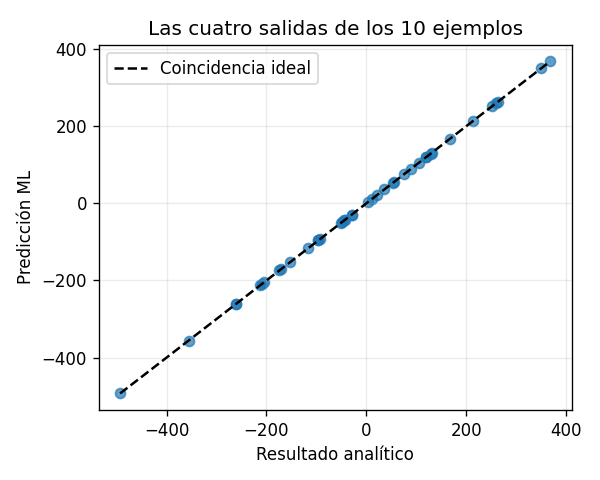

In [5]:
conocidos = set(map(tuple, X))
ejemplos = []
while len(ejemplos) < 10:
    fila = rng.integers(-20, 21, size=8)
    if tuple(fila) not in conocidos:
        ejemplos.append(fila)
        conocidos.add(tuple(fila))
X_nuevo = np.array(ejemplos)
Y_exacto = producto_analitico(X_nuevo)
Y_pred = modelo.predict(X_nuevo)

def matriz_texto(valores):
    return np.array2string(np.asarray(valores).reshape(2, 2), precision=6,
                           suppress_small=True).replace('\n', ' ')

comparacion = pd.DataFrame({
    'Caso': np.arange(1, 11),
    'A': [matriz_texto(x[:4]) for x in X_nuevo],
    'B': [matriz_texto(x[4:]) for x in X_nuevo],
    'Producto analítico': [matriz_texto(y) for y in Y_exacto],
    'Predicción ML': [matriz_texto(y) for y in Y_pred],
    'Error máximo': np.max(np.abs(Y_exacto - Y_pred), axis=1)
})
with pd.option_context('display.max_colwidth', None, 'display.width', 200):
    display(comparacion)
print('¿Los 10 casos coinciden con tolerancia absoluta de 1e-8?',
      np.allclose(Y_exacto, Y_pred, atol=1e-8, rtol=0))

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(Y_exacto.ravel(), Y_pred.ravel(), alpha=0.7)
limites = [Y_exacto.min(), Y_exacto.max()]
ax.plot(limites, limites, 'k--', label='Coincidencia ideal')
ax.set(xlabel='Resultado analítico', ylabel='Predicción ML',
       title='Las cuatro salidas de los 10 ejemplos')
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## 6. Comparar el costo computacional
**Conteo por par de matrices:** el método analítico requiere 8 multiplicaciones y 4 sumas. Con ocho entradas, la expansión polinómica genera $1+8+36=45$ características. Una evaluación densa de cuatro salidas requiere aproximadamente 180 multiplicaciones y 176 sumas, además de 36 multiplicaciones para formar los términos cuadráticos: **216 multiplicaciones y 176 sumas**. Es un conteo aritmético aproximado, sin incluir copias de memoria ni comprobaciones de las librerías.

Muchos pesos aprendidos son casi cero, pero la predicción estándar sigue siendo densa. Simplificar los términos recuperaría esencialmente la fórmula analítica.

También medimos tiempos con las mismas entradas en `float64`, calentamiento previo y la mediana de siete repeticiones. Comparamos un caso y un lote de 10.000 casos. El tiempo de ML incluye la transformación polinómica; generar datos y entrenar se mide por separado. Los tiempos dependen del equipo y de la carga de Colab.

In [6]:
def producto_numpy(x):
    A = x[:, :4].reshape(-1, 2, 2)
    B = x[:, 4:].reshape(-1, 2, 2)
    return (A @ B).reshape(-1, 4)

filas_tiempos = []
for cantidad, repeticiones in [(1, 1000), (10_000, 10)]:
    entrada = X_test[:cantidad].astype(np.float64)
    funciones = {'Fórmula analítica': producto_analitico,
                 'NumPy (A @ B)': producto_numpy,
                 'Modelo ML completo': modelo.predict}
    for nombre, funcion in funciones.items():
        funcion(entrada)  # Calentamiento.
        medidas = timeit.repeat(lambda: funcion(entrada),
                                repeat=7, number=repeticiones)
        segundos = np.median(medidas) / repeticiones
        filas_tiempos.append({'Método': nombre, 'Pares por llamada': cantidad,
                              'Tiempo por llamada (ms)': segundos * 1e3,
                              'Tiempo por par (µs)': segundos / cantidad * 1e6})

tiempos = pd.DataFrame(filas_tiempos)
display(tiempos)
print(f'Entrenar una vez añadió {tiempo_entrenamiento:.4f} segundos.')
for cantidad in [1, 10_000]:
    bloque = tiempos[tiempos['Pares por llamada'] == cantidad].set_index('Método')
    razon = (bloque.loc['Modelo ML completo', 'Tiempo por llamada (ms)'] /
             bloque.loc['Fórmula analítica', 'Tiempo por llamada (ms)'])
    print(f'Para {cantidad:,} pares: tiempo ML / tiempo analítico = {razon:.2f}')

Entrenar una vez añadió 0.0460 segundos.
Para 1 pares: tiempo ML / tiempo analítico = 15.32
Para 10,000 pares: tiempo ML / tiempo analítico = 18.21


Método,Pares por llamada,Tiempo por llamada (ms),Tiempo por par (µs)
Fórmula analítica,1,0.007664,7.664069
NumPy (A @ B),1,0.002007,2.007388
Modelo ML completo,1,0.117428,117.428201
Fórmula analítica,10000,0.104075,0.010407
NumPy (A @ B),10000,0.273510,0.027351
Modelo ML completo,10000,1.895412,0.189541


## 7. Interpretación y conclusión
El modelo aprende los coeficientes de los productos cruzados a partir de los datos. Como la familia elegida puede representar exactamente la multiplicación, se espera un error cercano a la precisión numérica. La tabla de diez casos y las métricas permiten comprobarlo en cada ejecución.

La multiplicación directa tiene menor costo aritmético y no requiere crear un dataset ni entrenar. La tabla de tiempos muestra cómo se refleja esto en el entorno de ejecución; sus valores no son universales. Para este problema conviene usar la fórmula conocida. El valor del ejercicio es mostrar cómo se aprende una operación mediante ejemplos y cómo se verifica ese aprendizaje.

La exactitud obtenida corresponde a esta operación y a la familia polinómica elegida; no demuestra que cualquier modelo de ML pueda aprender cualquier operación exactamente. En un problema sin una fórmula conocida, la elección de características y la calidad de los datos tendrían mayor importancia.